# Random Forest Classification using Mushroom Dataset

## Aim
To build a Random Forest Classification model using the Mushroom dataset and evaluate its performance.

## Objectives
- Read the dataset from a CSV file
- Understand the dataset structure
- Perform exploratory data analysis
- Encode categorical data into numerical format
- Train a Random Forest Classifier
- Evaluate the model performance
- Analyze feature importance

# Import Required Libraries

This cell imports all the essential Python libraries needed to perform the complete machine learning workflow for this project.

These libraries are used for different purposes such as:

- **Data manipulation and handling** using `pandas` and `numpy`
- **Data visualization** using `matplotlib` and `seaborn`
- **Model building and training** using `scikit-learn`
- **Model evaluation and interpretation** using performance metrics and feature importance tools

Using these libraries helps us efficiently perform:
- data preprocessing
- dataset analysis
- model training
- prediction
- performance evaluation
- algorithm interpretation

This is the foundational step of the project because all further analysis and model building depend on these imported tools.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance

# Read the Dataset

This cell is used to load the Mushroom dataset into the notebook using the `pandas` library.

The dataset is stored in a **CSV (Comma Separated Values)** file format, which is commonly used for data analysis and machine learning projects.

By reading the dataset, the raw data is converted into a **DataFrame**, which allows us to:

- display the data in tabular format
- access rows and columns easily
- perform preprocessing and analysis
- prepare the data for machine learning model training

After loading the dataset, the first few rows are displayed to verify that the file has been read correctly.

In [5]:
data = pd.read_csv(r"C:\Users\123\Downloads\archive (1)\mushroom.csv")
data.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w


# Statistical Summary of the Dataset

This cell provides a summary of the dataset values using descriptive statistics.

Although the Mushroom dataset mainly contains categorical values, this summary still helps in understanding:

- the count of non-missing entries
- how the dataset is structured
- the overall composition of the data

This step is useful for gaining a general overview of the dataset before preprocessing.

In [6]:
data.describe()

,cap-diameter,stem-height,stem-width
count,61069.000000,61069.000000,61069.000000
mean,6.733854,6.581538,12.149410
std,5.264845,3.370017,10.035955
min,0.380000,0.000000,0.000000
25%,3.480000,4.640000,5.210000
50%,5.860000,5.950000,10.190000
75%,8.540000,7.740000,16.570000
max,62.340000,33.920000,103.910000


# Check Class Distribution

This cell displays the number of mushrooms belonging to each target class.

The target variable in this dataset is **class**, where:

- **e** = edible
- **p** = poisonous

Checking the class distribution helps us understand whether the dataset is balanced or imbalanced.

A balanced dataset is usually better for training a reliable machine learning classification model.

In [7]:
print(data['class'].value_counts())

class
p    33888
e    27181
Name: count, dtype: int64


# Class Distribution Plot

This cell creates a bar chart to visually represent the number of edible and poisonous mushrooms in the dataset.

Data visualization helps in understanding the distribution of the target classes more clearly than numerical output alone.

This step is important because it gives a quick visual idea of how the classification labels are distributed in the dataset.

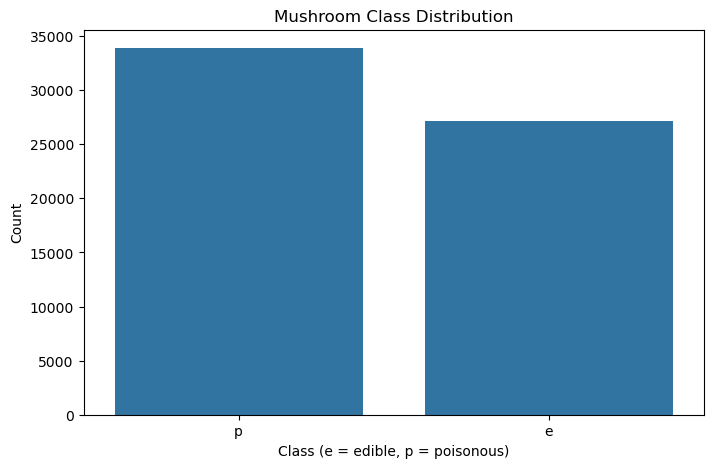

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(x='class', data=data)
plt.title("Mushroom Class Distribution")
plt.xlabel("Class (e = edible, p = poisonous)")
plt.ylabel("Count")

plt.show()

# Encode Categorical Data

This cell converts all categorical text values in the dataset into numerical values using **Label Encoding**.

The Mushroom dataset contains mostly categorical values such as letters and symbols.  
Machine learning algorithms like **Random Forest** cannot directly process text-based categories.

Therefore, this preprocessing step is necessary to transform the dataset into a numerical format that the model can understand.

This is an important part of data preprocessing in classification problems involving categorical data.

In [10]:
label_encoder = LabelEncoder()

for column in data.columns:
    data[column] = label_encoder.fit_transform(data[column])

data.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,1,1481,6,2,6,0,2,3,10,1577,...,4,7,11,0,4,1,2,7,0,3
1,1,1614,6,2,6,0,2,3,10,1681,...,4,7,11,0,4,1,2,7,0,2
2,1,1362,6,2,6,0,2,3,10,1662,...,4,7,11,0,4,1,2,7,0,3
3,1,1372,2,3,1,0,2,3,10,1463,...,4,7,11,0,4,1,5,7,0,3
4,1,1419,6,3,6,0,2,3,10,1537,...,4,7,11,0,4,1,5,7,0,3


# Correlation Heatmap

This cell creates a heatmap to show the correlation between the encoded features in the dataset.

A correlation heatmap helps us understand:

- how strongly features are related to one another
- which variables may behave similarly
- whether some features are more associated with the target than others

This step provides useful insight into the relationships between mushroom characteristics after encoding.

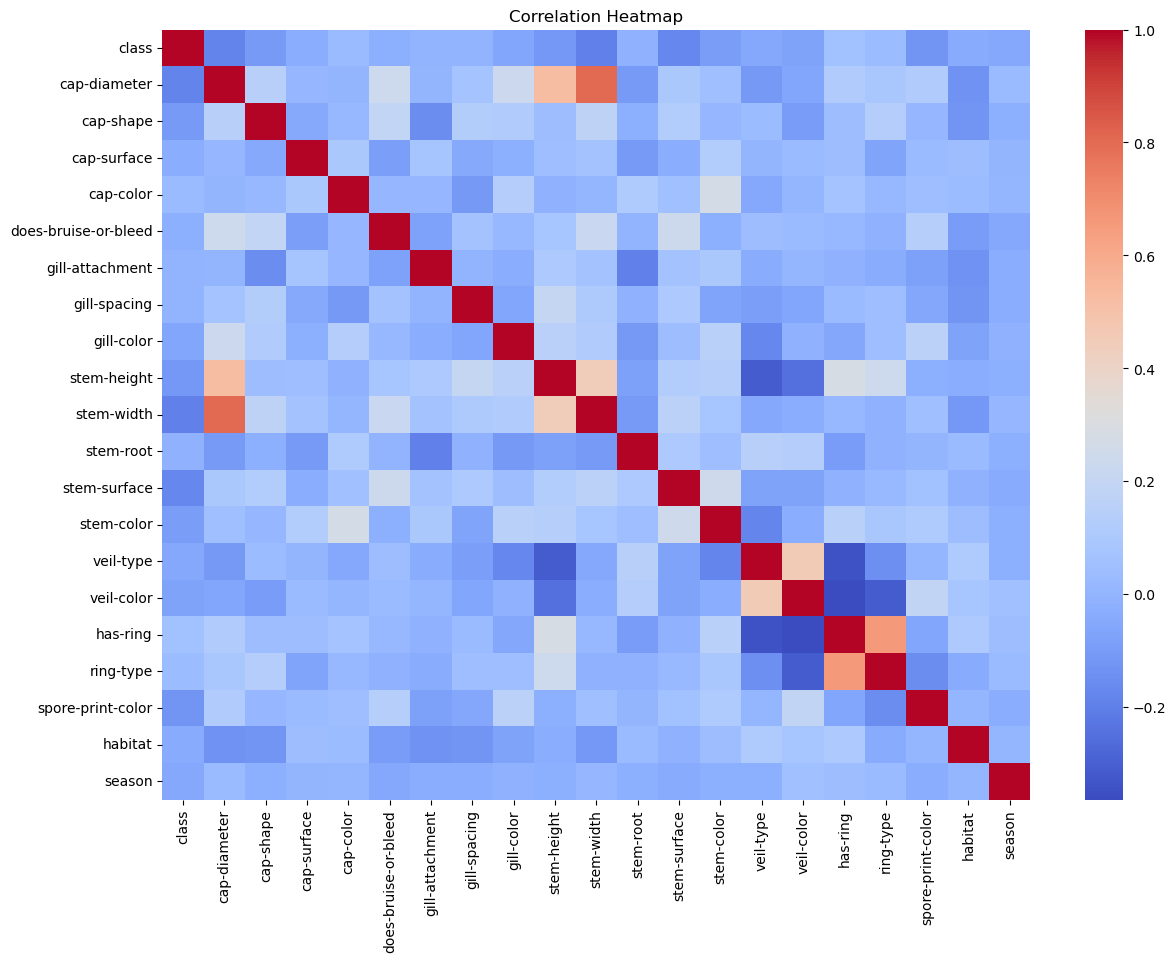

In [11]:
plt.figure(figsize=(14,10))
sns.heatmap(data.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Define Features and Target Variable

This cell separates the dataset into:

- **X (Features)** → the input variables used for prediction
- **y (Target Variable)** → the output variable to be predicted

In this project:

- **X** contains the mushroom characteristics
- **y** contains the class label indicating whether the mushroom is edible or poisonous

This is a necessary step before splitting the dataset and training the machine learning model.

In [12]:
X = data.drop("class", axis=1)
y = data["class"]

print("Features:\n")
print(X.head())

print("\nTarget:\n")
print(y.head())

Features:

   cap-diameter  cap-shape  cap-surface  cap-color  does-bruise-or-bleed  \
0          1481          6            2          6                     0   
1          1614          6            2          6                     0   
2          1362          6            2          6                     0   
3          1372          2            3          1                     0   
4          1419          6            3          6                     0   

   gill-attachment  gill-spacing  gill-color  stem-height  stem-width  \
0                2             3          10         1577        1656   
1                2             3          10         1681        1766   
2                2             3          10         1662        1721   
3                2             3          10         1463        1545   
4                2             3          10         1537        1667   

   stem-root  stem-surface  stem-color  veil-type  veil-color  has-ring  \
0          4      

# Split the Dataset into Training and Testing Sets

This cell divides the dataset into two parts:

- **Training Data (80%)** → used to train the Random Forest model
- **Testing Data (20%)** → used to evaluate the model performance on unseen data

Splitting the dataset is important because it helps us test how well the model generalizes to new data rather than only memorizing the training data.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape :", X_test.shape)

Training Data Shape: (48855, 20)
Testing Data Shape : (12214, 20)


# Train the Random Forest Model

This cell creates and trains the **Random Forest Classifier** using the training dataset.

Random Forest is a **supervised machine learning algorithm** used for classification and regression tasks.

It works by building multiple **decision trees** and combining their predictions to improve accuracy and reduce overfitting.

In this project, the Random Forest model is trained to classify mushrooms as:

- edible
- poisonous

In [14]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [39]:
print("Random Forest Model Parameters:\n")
print(model.get_params())

Random Forest Model Parameters:

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': True, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [40]:
print("Number of Trees in the Random Forest:", len(model.estimators_))

Number of Trees in the Random Forest: 100


# Make Predictions on Test Data

This cell uses the trained Random Forest model to make predictions on the testing dataset.

The model predicts whether each mushroom sample in the test set is:

- edible
- poisonous

These predictions are then used to evaluate how well the model performs on unseen data.

In [15]:
predictions = model.predict(X_test)
predictions[:10]

array([0, 1, 0, 1, 0, 1, 0, 1, 1, 0])

# Evaluate Model Accuracy

This cell calculates the **accuracy** of the Random Forest model.

Accuracy measures the proportion of correctly classified mushroom samples out of the total number of test samples.

It is one of the most common evaluation metrics used in classification problems.

A higher accuracy value indicates that the model is performing well in distinguishing between edible and poisonous mushrooms.

In [16]:
accuracy = accuracy_score(y_test, predictions)
print("Model Accuracy:", accuracy)

Model Accuracy: 1.0


# Confusion Matrix

This cell creates a **confusion matrix** to evaluate the classification performance of the Random Forest model.

A confusion matrix helps us understand:

- how many predictions were correct
- how many predictions were incorrect
- how the model performed for each class separately

It provides a more detailed view of model performance than accuracy alone.

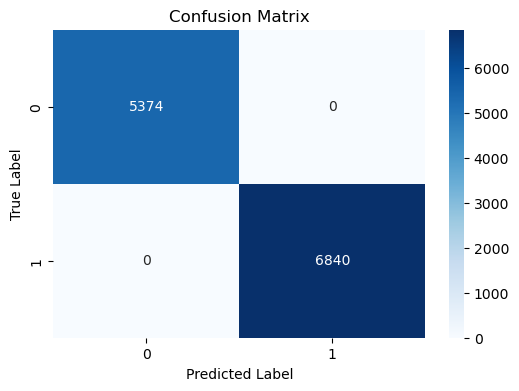

In [17]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Classification Report

This cell prints the **classification report**, which provides detailed evaluation metrics for the model.

The report includes:

- **Precision** → how many predicted positives were actually correct
- **Recall** → how many actual positives were correctly identified
- **F1-score** → the balance between precision and recall
- **Support** → the number of actual samples in each class

These metrics provide a deeper understanding of the model’s performance than accuracy alone.

In [18]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5374
           1       1.00      1.00      1.00      6840

    accuracy                           1.00     12214
   macro avg       1.00      1.00      1.00     12214
weighted avg       1.00      1.00      1.00     12214



# Feature Importance Analysis

This cell displays the importance score of each feature used by the Random Forest model.

One of the major advantages of Random Forest is that it can estimate which input features contribute the most to the prediction process.

Feature importance helps us identify:

- which mushroom characteristics are most influential
- which variables play a major role in classification
- which features are less useful for prediction

This step makes the model more interpretable and meaningful.

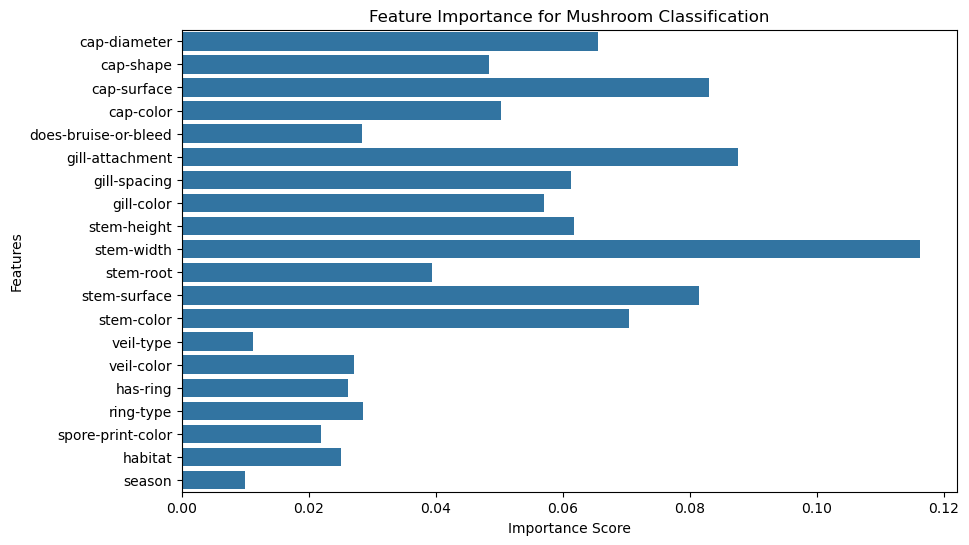

In [19]:
importance = model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(10,6))
sns.barplot(x=importance, y=feature_names)
plt.title("Feature Importance for Mushroom Classification")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

# Permutation Feature Importance

This cell calculates **permutation-based feature importance**.

Permutation importance works by randomly shuffling one feature at a time and measuring how much the model performance decreases.

If the model accuracy drops significantly after shuffling a feature, it means that feature is important for prediction.

This method provides another reliable way to understand which mushroom features are most useful for classification.

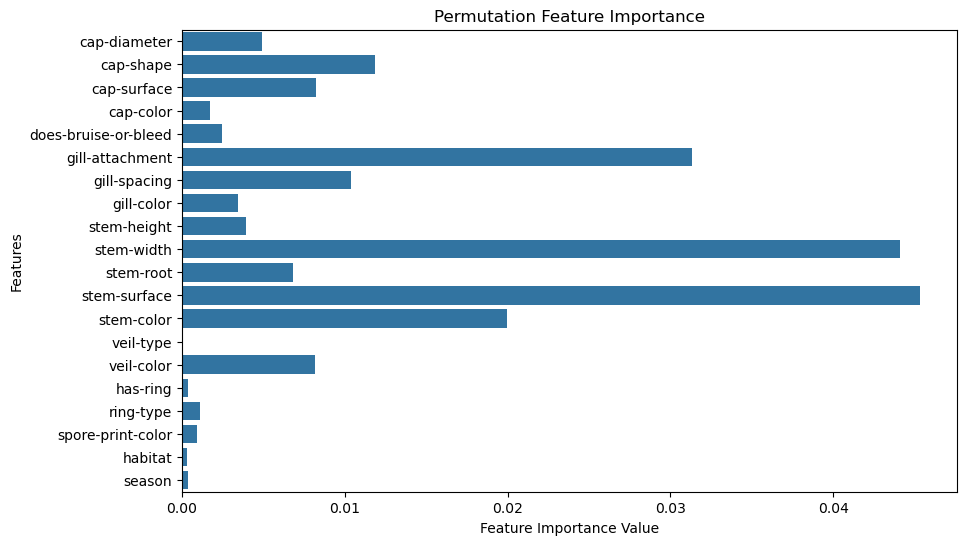

In [38]:
perm_importance = permutation_importance(
    model, X_test, y_test, n_repeats=10, random_state=42
)

perm_scores = perm_importance.importances_mean

plt.figure(figsize=(10,6))
sns.barplot(x=perm_scores, y=X.columns)
plt.title("Permutation Feature Importance")
plt.xlabel("Feature Importance Value")
plt.ylabel("Features")
plt.show()

# Compare Training and Testing Accuracy

This cell calculates the model accuracy on both the training dataset and the testing dataset.

Comparing these two values helps us understand whether the model is:

- **well-generalized**
- **overfitting** (too dependent on training data)
- **underfitting** (not learning enough from the data)

A good machine learning model should perform well on both training and testing data.

In [21]:
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy :", test_accuracy)

Training Accuracy: 1.0
Testing Accuracy : 1.0


# Accuracy Comparison Plot

This cell creates a bar chart to visually compare the model’s:

- **Training Accuracy**
- **Testing Accuracy**

This visual comparison makes it easier to understand the consistency and reliability of the Random Forest model.

If both values are close, it usually indicates that the model is performing in a stable and generalizable way.

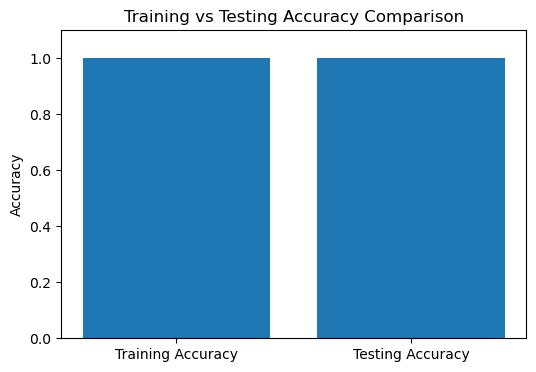

In [22]:
accuracy_values = [train_accuracy, test_accuracy]
labels = ["Training Accuracy", "Testing Accuracy"]

plt.figure(figsize=(6,4))
plt.bar(labels, accuracy_values)
plt.title("Training vs Testing Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1.1)
plt.show()

# Final Results Summary Table

This cell creates a summary table containing the final evaluation metrics of the model.

The table includes:

- **Training Accuracy**
- **Testing Accuracy**
- **Model Accuracy**

This step provides a concise and organized view of the model’s final performance and makes the notebook more professional and presentation-ready.

In [23]:
results = pd.DataFrame({
    "Metric": ["Training Accuracy", "Testing Accuracy", "Model Accuracy"],
    "Value": [train_accuracy, test_accuracy, accuracy]
})

results

,Metric,Value
0,Training Accuracy,1.0
1,Testing Accuracy,1.0
2,Model Accuracy,1.0


# Train the Random Forest Model with Out-of-Bag Score

This cell creates and trains the **Random Forest Classifier** using the training dataset.

Random Forest is an **ensemble learning algorithm** that works by building multiple **decision trees** and combining their predictions to make the final classification more accurate and stable.

In this model:

- **n_estimators = 100** means the algorithm will build **100 decision trees**
- **random_state = 42** ensures that the results remain the same every time the code is run
- **oob_score = True** enables **Out-of-Bag (OOB) validation**

## What is Out-of-Bag Score?
Out-of-Bag scoring is a special validation method used in Random Forest.

When each decision tree is trained, it does not use the entire training dataset.  
Instead, it uses a random subset of the data, and some samples are left out.

These left-out samples are called **Out-of-Bag samples**, and they are used to estimate the model’s performance internally without needing a separate validation dataset.

## Why this cell is important
This step is important because it:

- trains the Random Forest model
- prepares it for prediction and evaluation
- adds an internal validation mechanism using OOB scoring
- makes the notebook more technically strong and algorithm-focused

This improves both the quality of the model and the overall presentation of the project.

In [36]:
model = RandomForestClassifier(n_estimators=100, random_state=42, oob_score=True)
model.fit(X_train, y_train)

RandomForestClassifier(oob_score=True, random_state=42)

In [37]:
print("Out-of-Bag Score:", model.oob_score_)

Out-of-Bag Score: 0.9999385937979736
